1. Jakie techniki znikają najczęściej z tekstów między anotacjami?
2. Jakie techniki się pojawiają?
3. Jakie techniki są "zamieniane"?
4. Rozkłady i liczności technik
5. Preferencje technik/biasy w grupach anotatorów
6. Niezgodności w grupach z resztą

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# Load data
data = pd.read_csv('../data/AB_comparison.csv')
print(f'Liczba obserwacji: {len(data)}')
print(f'Liczba unikalnych tekstów: {data["id"].nunique()}')
print(f'Liczba anotatorów: {data["annotator"].nunique()}')
print(f'Grupy anotatorów: {data["annotator_group"].unique()}')

Liczba obserwacji: 750
Liczba unikalnych tekstów: 150
Liczba anotatorów: 25
Grupy anotatorów: ['komunikacja' 'rodzic' 'psycholog' 'nauczyciel' 'nastolatek']


In [2]:
def extract_techniques(text):
    """Extract list of techniques from text field"""
    if pd.isna(text) or not text:
        return []
    return [t.strip() for t in text.split('\n') if t.strip() and not t.endswith(':')]

# Add technique lists to dataframe
data['first_techniques_list'] = data['first_question_2_techniques'].apply(extract_techniques)
data['repeated_techniques_list'] = data['repeated_question_2_techniques'].apply(extract_techniques)

# Calculate counts
data['first_num_techniques'] = data['first_techniques_list'].apply(len)
data['repeated_num_techniques'] = data['repeated_techniques_list'].apply(len)
data['technique_diff'] = data['repeated_num_techniques'] - data['first_num_techniques']

# Get all unique techniques
all_techniques = set()
for techniques in data['first_techniques_list']:
    all_techniques.update(techniques)
for techniques in data['repeated_techniques_list']:
    all_techniques.update(techniques)
all_techniques = sorted(all_techniques)
print(f'Unikalne techniki ({len(all_techniques)}):')
for i, t in enumerate(all_techniques, 1):
    print(f'  {i}. {t}')

Unikalne techniki (20):
  1. Autorytet
  2. Dać, aby wziąć
  3. Drzwi zatrzaśnięte przed nosem
  4. Efekt „wszyscy to wiedzą”
  5. Etykietowanie
  6. Humor
  7. Huśtawka emocjonalna
  8. Jesteśmy wyjątkowi
  9. Komplementowanie
  10. Odwoływanie się do lęku
  11. Odwoływanie się do uczucia miłości
  12. Okazywanie wdzięczności
  13. Poczucie winy
  14. Podobieństwa
  15. Przewidywanie żalu
  16. Reguła lubienia
  17. Reguła „my”
  18. Rozczarowanie
  19. Szukamy takich jak ty
  20. U nas tak się robi


## 1. Rozkłady ogólne technik

In [3]:
# Count overall frequency of each technique
first_counter = Counter()
repeated_counter = Counter()

for techniques in data['first_techniques_list']:
    first_counter.update(techniques)
for techniques in data['repeated_techniques_list']:
    repeated_counter.update(techniques)

# Create comparison dataframe
technique_comparison = pd.DataFrame({
    'technique': all_techniques,
    'first_count': [first_counter[t] for t in all_techniques],
    'repeated_count': [repeated_counter[t] for t in all_techniques]
})
technique_comparison['diff'] = technique_comparison['repeated_count'] - technique_comparison['first_count']
technique_comparison['diff_pct'] = (technique_comparison['diff'] / technique_comparison['first_count'].replace(0, np.nan) * 100).round(1)
technique_comparison = technique_comparison.sort_values('diff', ascending=True)

print('Porównanie częstości technik (first vs repeated):')
print(technique_comparison.to_string(index=False))
print(f'\nSuma first: {technique_comparison["first_count"].sum()}')
print(f'Suma repeated: {technique_comparison["repeated_count"].sum()}')

Porównanie częstości technik (first vs repeated):
                         technique  first_count  repeated_count  diff  diff_pct
                   Reguła lubienia          103              77   -26     -25.2
             Szukamy takich jak ty           83              66   -17     -20.5
                         Autorytet           89              78   -11     -12.4
                Przewidywanie żalu          153             143   -10      -6.5
                     Poczucie winy          133             124    -9      -6.8
                Jesteśmy wyjątkowi          134             125    -9      -6.7
                      Podobieństwa           69              64    -5      -7.2
              Huśtawka emocjonalna           44              39    -5     -11.4
                  Komplementowanie          157             154    -3      -1.9
           Okazywanie wdzięczności           62              60    -2      -3.2
                             Humor           32              31    -1 

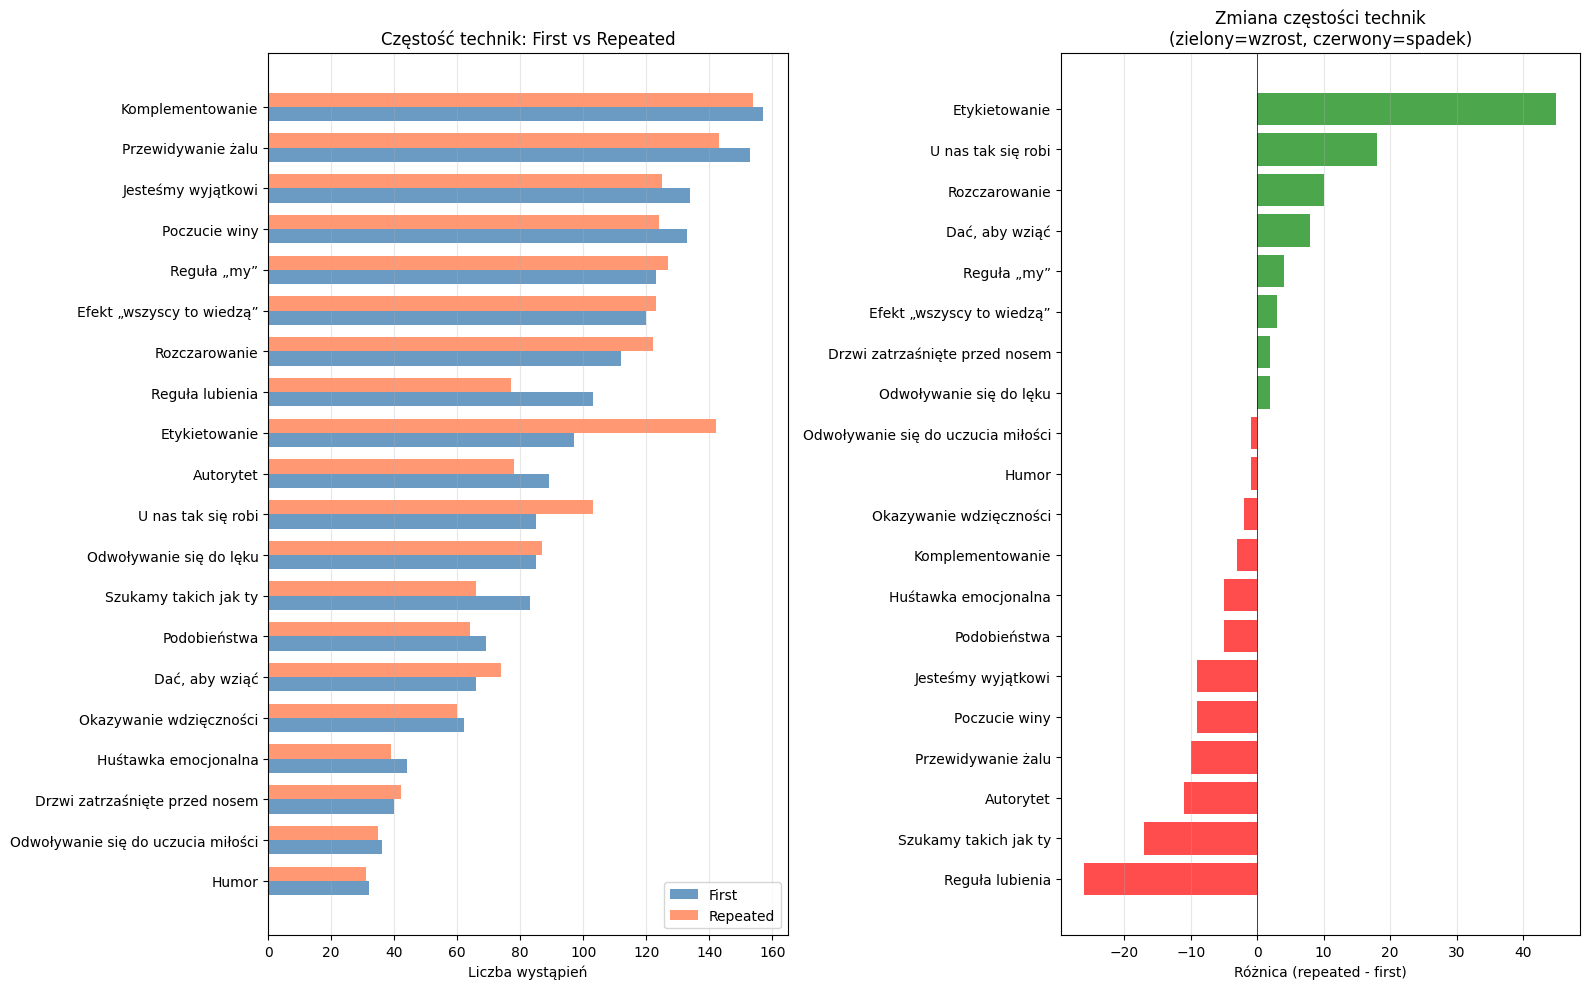

In [4]:
# Visualization: technique frequency comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: Bar chart comparison
technique_comparison_sorted = technique_comparison.sort_values('first_count', ascending=True)
y_pos = np.arange(len(technique_comparison_sorted))
width = 0.35

axes[0].barh(y_pos - width/2, technique_comparison_sorted['first_count'], width, label='First', color='steelblue', alpha=0.8)
axes[0].barh(y_pos + width/2, technique_comparison_sorted['repeated_count'], width, label='Repeated', color='coral', alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(technique_comparison_sorted['technique'])
axes[0].set_xlabel('Liczba wystąpień')
axes[0].set_title('Częstość technik: First vs Repeated')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Right: Difference chart
technique_comparison_by_diff = technique_comparison.sort_values('diff')
colors = ['green' if x > 0 else 'red' for x in technique_comparison_by_diff['diff']]
axes[1].barh(technique_comparison_by_diff['technique'], technique_comparison_by_diff['diff'], color=colors, alpha=0.7)
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Różnica (repeated - first)')
axes[1].set_title('Zmiana częstości technik\n(zielony=wzrost, czerwony=spadek)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/techniques_frequency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Analiza znikania i pojawiania się technik (per obserwacja)

In [5]:
# For each observation, calculate which techniques disappeared/appeared
def get_disappeared(row):
    first_set = set(row['first_techniques_list'])
    repeated_set = set(row['repeated_techniques_list'])
    return list(first_set - repeated_set)

def get_appeared(row):
    first_set = set(row['first_techniques_list'])
    repeated_set = set(row['repeated_techniques_list'])
    return list(repeated_set - first_set)

def get_kept(row):
    first_set = set(row['first_techniques_list'])
    repeated_set = set(row['repeated_techniques_list'])
    return list(first_set & repeated_set)

data['disappeared'] = data.apply(get_disappeared, axis=1)
data['appeared'] = data.apply(get_appeared, axis=1)
data['kept'] = data.apply(get_kept, axis=1)

data['num_disappeared'] = data['disappeared'].apply(len)
data['num_appeared'] = data['appeared'].apply(len)
data['num_kept'] = data['kept'].apply(len)

print('Statystyki zmian technik per obserwacja:')
print(f'  Średnia liczba znikających: {data["num_disappeared"].mean():.2f}')
print(f'  Średnia liczba pojawiających się: {data["num_appeared"].mean():.2f}')
print(f'  Średnia liczba zachowanych: {data["num_kept"].mean():.2f}')
print(f'\n  Obserwacje bez zmian: {(data["num_disappeared"] == 0) & (data["num_appeared"] == 0).sum()}')
print(f'  Obserwacje z jakimikolwiek zmianami: {((data["num_disappeared"] > 0) | (data["num_appeared"] > 0)).sum()}')

Statystyki zmian technik per obserwacja:
  Średnia liczba znikających: 1.49
  Średnia liczba pojawiających się: 1.48
  Średnia liczba zachowanych: 0.94

  Obserwacje bez zmian: 0       True
1      False
2      False
3      False
4       True
       ...  
745     True
746     True
747    False
748     True
749     True
Name: num_disappeared, Length: 750, dtype: bool
  Obserwacje z jakimikolwiek zmianami: 669


In [6]:
# Count which techniques disappear/appear most often
disappeared_counter = Counter()
appeared_counter = Counter()
kept_counter = Counter()

for techniques in data['disappeared']:
    disappeared_counter.update(techniques)
for techniques in data['appeared']:
    appeared_counter.update(techniques)
for techniques in data['kept']:
    kept_counter.update(techniques)

# Create summary
change_analysis = pd.DataFrame({
    'technique': all_techniques,
    'first_count': [first_counter[t] for t in all_techniques],
    'disappeared': [disappeared_counter[t] for t in all_techniques],
    'kept': [kept_counter[t] for t in all_techniques],
    'appeared': [appeared_counter[t] for t in all_techniques],
    'repeated_count': [repeated_counter[t] for t in all_techniques]
})

# Calculate rates
change_analysis['disappear_rate'] = (change_analysis['disappeared'] / change_analysis['first_count'].replace(0, np.nan) * 100).round(1)
change_analysis['keep_rate'] = (change_analysis['kept'] / change_analysis['first_count'].replace(0, np.nan) * 100).round(1)
change_analysis['net_change'] = change_analysis['appeared'] - change_analysis['disappeared']

print('Analiza zmian technik:')
print(change_analysis.sort_values('disappear_rate', ascending=False).to_string(index=False))

Analiza zmian technik:
                         technique  first_count  disappeared  kept  appeared  repeated_count  disappear_rate  keep_rate  net_change
              Huśtawka emocjonalna           44           38     6        33              39            86.4       13.6          -5
Odwoływanie się do uczucia miłości           36           30     6        29              35            83.3       16.7          -1
                   Reguła lubienia          103           85    18        59              77            82.5       17.5         -26
                     Etykietowanie           97           75    22       120             142            77.3       22.7          45
             Szukamy takich jak ty           83           58    25        41              66            69.9       30.1         -17
                      Podobieństwa           69           48    21        43              64            69.6       30.4          -5
                U nas tak się robi           85      

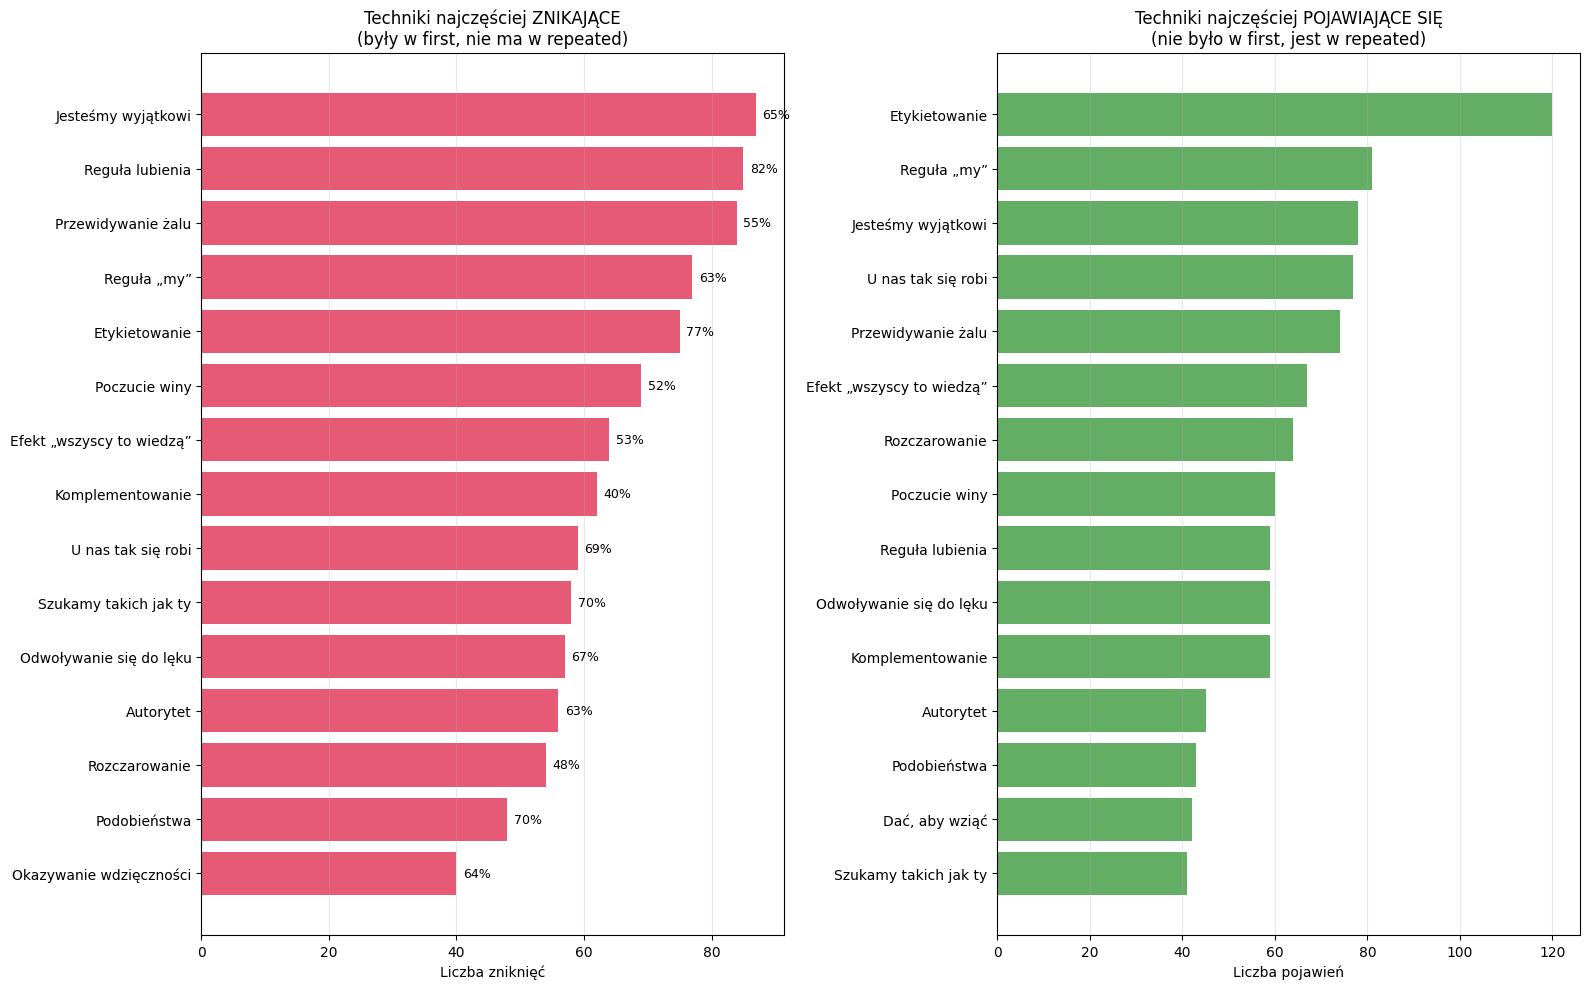

In [7]:
# Visualization: disappearing vs appearing
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Top disappearing
top_disappeared = change_analysis.nlargest(15, 'disappeared').sort_values('disappeared')
axes[0].barh(top_disappeared['technique'], top_disappeared['disappeared'], color='crimson', alpha=0.7)
axes[0].set_xlabel('Liczba zniknięć')
axes[0].set_title('Techniki najczęściej ZNIKAJĄCE\n(były w first, nie ma w repeated)')
axes[0].grid(axis='x', alpha=0.3)
# Add rate labels
for i, (_, row) in enumerate(top_disappeared.iterrows()):
    axes[0].text(row['disappeared'] + 1, i, f"{row['disappear_rate']:.0f}%", va='center', fontsize=9)

# Top appearing
top_appeared = change_analysis.nlargest(15, 'appeared').sort_values('appeared')
axes[1].barh(top_appeared['technique'], top_appeared['appeared'], color='forestgreen', alpha=0.7)
axes[1].set_xlabel('Liczba pojawień')
axes[1].set_title('Techniki najczęściej POJAWIAJĄCE SIĘ\n(nie było w first, jest w repeated)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/techniques_appearing_disappearing.png', dpi=150, bbox_inches='tight')
plt.show()

Stabilność technik (keep rate, min 20 wystąpień w first):
                         technique  first_count  kept  keep_rate
                  Komplementowanie          157    95       60.5
    Drzwi zatrzaśnięte przed nosem           40    23       57.5
                     Rozczarowanie          112    58       51.8
                    Dać, aby wziąć           66    32       48.5
                     Poczucie winy          133    64       48.1
         Efekt „wszyscy to wiedzą”          120    56       46.7
                Przewidywanie żalu          153    69       45.1
                       Reguła „my”          123    46       37.4
                         Autorytet           89    33       37.1
           Okazywanie wdzięczności           62    22       35.5
                Jesteśmy wyjątkowi          134    47       35.1
                             Humor           32    11       34.4
           Odwoływanie się do lęku           85    28       32.9
                U nas tak się ro

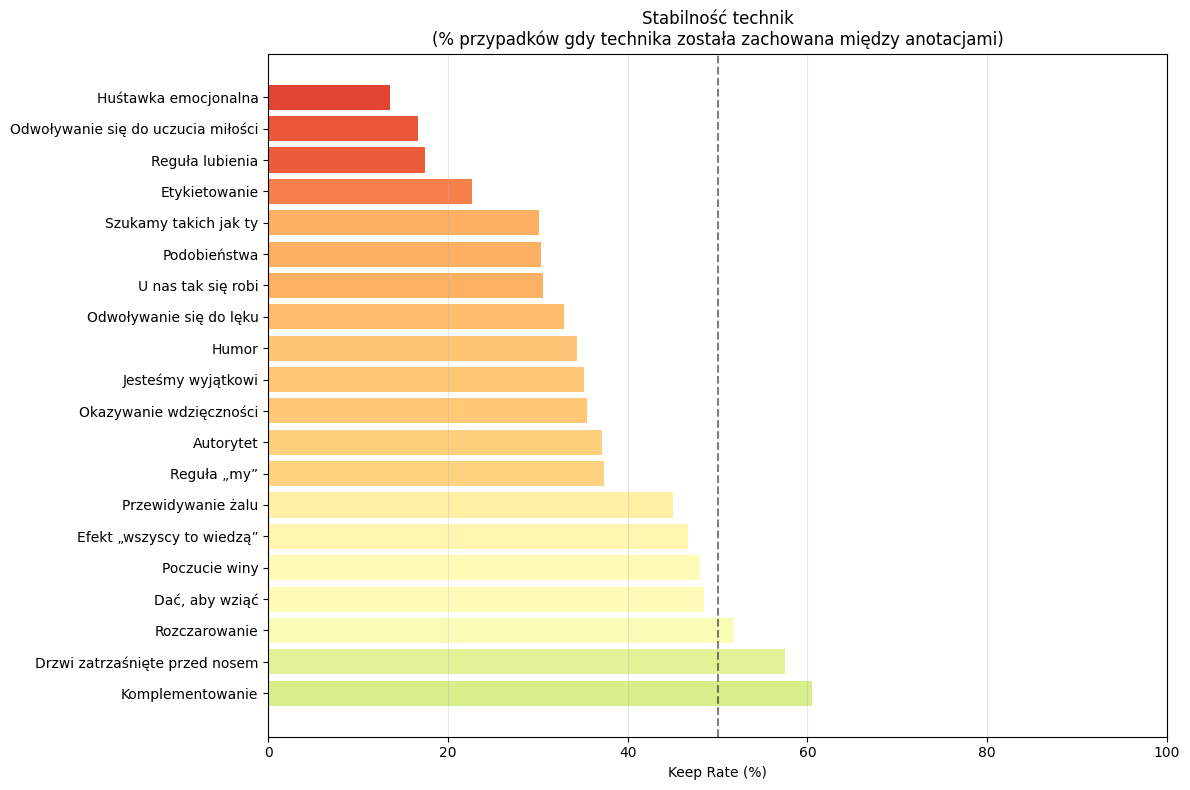

In [8]:
# Stability analysis - which techniques are most "stable" (highest keep rate)
stability = change_analysis[change_analysis['first_count'] >= 20].copy()  # min 20 occurrences
stability = stability.sort_values('keep_rate', ascending=False)

print('Stabilność technik (keep rate, min 20 wystąpień w first):')
print(stability[['technique', 'first_count', 'kept', 'keep_rate']].to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(stability['keep_rate'].values / 100)
bars = ax.barh(stability['technique'], stability['keep_rate'], color=colors)
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='50%')
ax.set_xlabel('Keep Rate (%)')
ax.set_title('Stabilność technik\n(% przypadków gdy technika została zachowana między anotacjami)')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('../results/techniques_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analiza "zamian" technik (co zastępuje co)

In [9]:
# Build substitution matrix: when technique A disappears, what appears?
# This captures potential "replacements" or confusions

substitution_counts = defaultdict(lambda: defaultdict(int))
cooccurrence_first = defaultdict(lambda: defaultdict(int))
cooccurrence_repeated = defaultdict(lambda: defaultdict(int))

for _, row in data.iterrows():
    disappeared = set(row['disappeared'])
    appeared = set(row['appeared'])
    
    # For each disappearing technique, count what appeared
    for d in disappeared:
        for a in appeared:
            substitution_counts[d][a] += 1
    
    # Co-occurrence in first
    first_set = row['first_techniques_list']
    for t1, t2 in combinations(first_set, 2):
        cooccurrence_first[t1][t2] += 1
        cooccurrence_first[t2][t1] += 1
    
    # Co-occurrence in repeated
    repeated_set = row['repeated_techniques_list']
    for t1, t2 in combinations(repeated_set, 2):
        cooccurrence_repeated[t1][t2] += 1
        cooccurrence_repeated[t2][t1] += 1

# Create substitution matrix
subst_matrix = pd.DataFrame(0, index=all_techniques, columns=all_techniques)
for d in substitution_counts:
    for a in substitution_counts[d]:
        subst_matrix.loc[d, a] = substitution_counts[d][a]

# Show top substitutions
substitutions_list = []
for d in substitution_counts:
    for a in substitution_counts[d]:
        if substitution_counts[d][a] >= 5:  # minimum threshold
            substitutions_list.append({
                'disappeared': d,
                'appeared': a,
                'count': substitution_counts[d][a]
            })

substitutions_df = pd.DataFrame(substitutions_list).sort_values('count', ascending=False)
print('Najczęstsze "zamiany" technik (min 5 wystąpień):')
print('(gdy technika X znika, pojawia się technika Y)')
print(substitutions_df.head(30).to_string(index=False))

Najczęstsze "zamiany" technik (min 5 wystąpień):
(gdy technika X znika, pojawia się technika Y)
              disappeared                  appeared  count
          Reguła lubienia        Przewidywanie żalu     15
       Przewidywanie żalu Efekt „wszyscy to wiedzą”     13
  Odwoływanie się do lęku             Poczucie winy     12
       Przewidywanie żalu             Rozczarowanie     12
  Odwoływanie się do lęku               Reguła „my”     11
       Jesteśmy wyjątkowi        U nas tak się robi     11
       Przewidywanie żalu        U nas tak się robi     11
          Reguła lubienia   Odwoływanie się do lęku     11
              Reguła „my”        Jesteśmy wyjątkowi     10
            Poczucie winy Efekt „wszyscy to wiedzą”     10
       Przewidywanie żalu             Poczucie winy     10
              Reguła „my”        U nas tak się robi     10
       U nas tak się robi             Poczucie winy     10
              Reguła „my”          Komplementowanie     10
            Rozczar

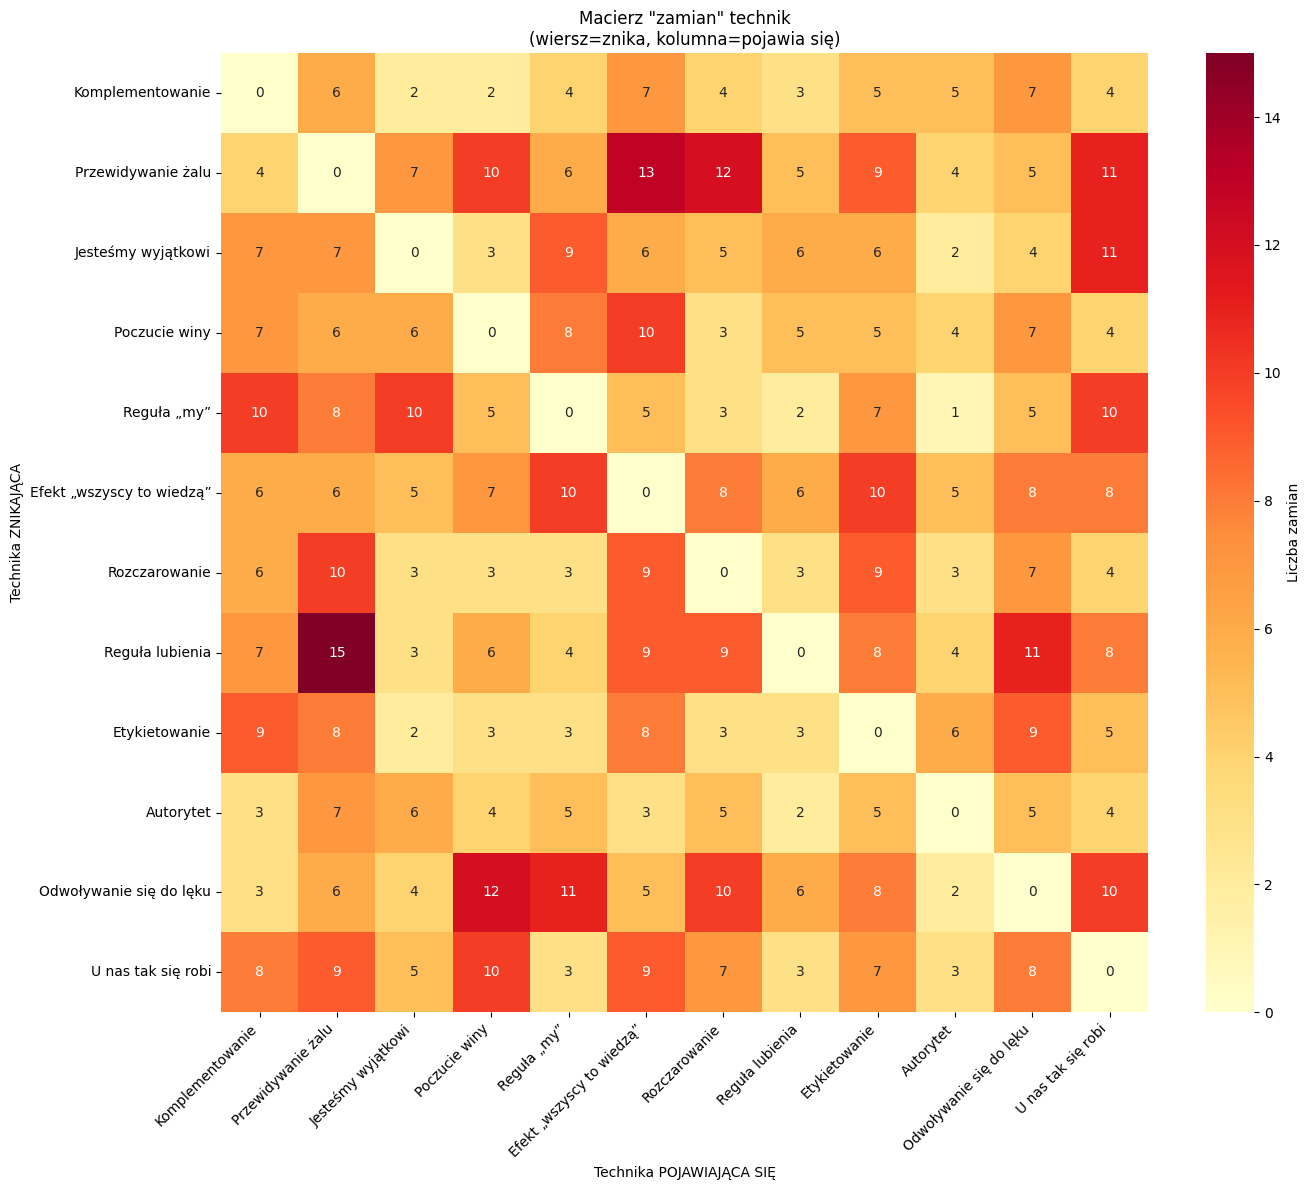

In [10]:
# Heatmap of substitutions (filtered for readability)
# Select techniques with most activity
active_techniques = list(change_analysis.nlargest(12, 'first_count')['technique'])

subst_matrix_filtered = subst_matrix.loc[active_techniques, active_techniques]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(subst_matrix_filtered, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Liczba zamian'})
ax.set_xlabel('Technika POJAWIAJĄCA SIĘ')
ax.set_ylabel('Technika ZNIKAJĄCA')
ax.set_title('Macierz "zamian" technik\n(wiersz=znika, kolumna=pojawia się)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../results/techniques_substitution_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Find bidirectional substitutions (A->B and B->A both happen)
bidirectional = []
checked = set()

for d in substitution_counts:
    for a in substitution_counts[d]:
        pair = tuple(sorted([d, a]))
        if pair not in checked:
            checked.add(pair)
            count_da = substitution_counts[d].get(a, 0)
            count_ad = substitution_counts[a].get(d, 0)
            if count_da >= 3 and count_ad >= 3:
                bidirectional.append({
                    'technique_1': d,
                    'technique_2': a,
                    'count_1_to_2': count_da,
                    'count_2_to_1': count_ad,
                    'total': count_da + count_ad
                })

bidirectional_df = pd.DataFrame(bidirectional).sort_values('total', ascending=False)
print('Dwukierunkowe "zamiany" (techniki mylone ze sobą nawzajem):')
print(bidirectional_df.to_string(index=False))

Dwukierunkowe "zamiany" (techniki mylone ze sobą nawzajem):
                       technique_1                        technique_2  count_1_to_2  count_2_to_1  total
                Przewidywanie żalu                      Rozczarowanie            12            10     22
                Przewidywanie żalu                    Reguła lubienia             5            15     20
                U nas tak się robi                 Przewidywanie żalu             9            11     20
                Jesteśmy wyjątkowi                        Reguła „my”             9            10     19
           Odwoływanie się do lęku                      Poczucie winy            12             7     19
         Efekt „wszyscy to wiedzą”                 Przewidywanie żalu             6            13     19
         Efekt „wszyscy to wiedzą”                      Etykietowanie            10             8     18
                U nas tak się robi            Odwoływanie się do lęku             8            10   

## 4. Analiza per grupa anotatorów

In [12]:
# Technique frequency per group
def count_techniques_per_group(data, technique_col, group_col):
    result = {}
    for group in data[group_col].unique():
        group_data = data[data[group_col] == group]
        counter = Counter()
        for techniques in group_data[technique_col]:
            counter.update(techniques)
        result[group] = counter
    return result

first_per_group = count_techniques_per_group(data, 'first_techniques_list', 'annotator_group')
repeated_per_group = count_techniques_per_group(data, 'repeated_techniques_list', 'annotator_group')

# Create dataframe for first
groups = list(first_per_group.keys())
group_first_df = pd.DataFrame(index=all_techniques)
for group in groups:
    group_first_df[group] = [first_per_group[group].get(t, 0) for t in all_techniques]
group_first_df['total'] = group_first_df.sum(axis=1)

print('Częstość technik per grupa (FIRST annotation):')
print(group_first_df.sort_values('total', ascending=False).to_string())

Częstość technik per grupa (FIRST annotation):
                                    komunikacja  rodzic  psycholog  nauczyciel  nastolatek  total
Komplementowanie                             29      31         35          30          32    157
Przewidywanie żalu                           29      31         32          33          28    153
Jesteśmy wyjątkowi                           18      39         23          19          35    134
Poczucie winy                                21      26         25          30          31    133
Reguła „my”                                  19      36         26          17          25    123
Efekt „wszyscy to wiedzą”                    17      33         17          18          35    120
Rozczarowanie                                17      24         28          16          27    112
Reguła lubienia                              10      29         20          10          34    103
Etykietowanie                                 8      27         16     

In [13]:
# Calculate normalized preferences (% of all techniques used by group)
group_totals_first = {group: sum(first_per_group[group].values()) for group in groups}
group_totals_repeated = {group: sum(repeated_per_group[group].values()) for group in groups}

# Preference deviation from average
overall_pct = group_first_df['total'] / group_first_df['total'].sum() * 100

group_pct_first = pd.DataFrame(index=all_techniques)
for group in groups:
    group_pct_first[group] = [first_per_group[group].get(t, 0) / group_totals_first[group] * 100 
                               for t in all_techniques]
group_pct_first['overall'] = overall_pct.values

# Calculate deviation from overall
deviation_first = pd.DataFrame(index=all_techniques)
for group in groups:
    deviation_first[group] = group_pct_first[group] - group_pct_first['overall']

print('Odchylenie od średniej (% użycia techniki vs overall) - FIRST:')
print('(wartości dodatnie = grupa używa częściej niż średnia)')
print(deviation_first.round(2).to_string())

Odchylenie od średniej (% użycia techniki vs overall) - FIRST:
(wartości dodatnie = grupa używa częściej niż średnia)
                                    komunikacja  rodzic  psycholog  nauczyciel  nastolatek
Autorytet                                 -1.87    0.28       1.65       -0.23       -0.33
Dać, aby wziąć                             1.27    0.04       0.36        1.03       -1.80
Drzwi zatrzaśnięte przed nosem             1.19   -0.26      -0.21       -0.20       -0.14
Efekt „wszyscy to wiedzą”                 -0.19    0.51      -1.75       -0.60        1.39
Etykietowanie                             -2.31    0.49      -0.78       -0.01        1.51
Humor                                     -0.25    0.18      -0.05       -0.76        0.52
Huśtawka emocjonalna                      -1.29    0.38      -0.14       -1.42        1.46
Jesteśmy wyjątkowi                        -0.58    1.04      -0.82       -1.04        0.62
Komplementowanie                           2.29   -1.95       1

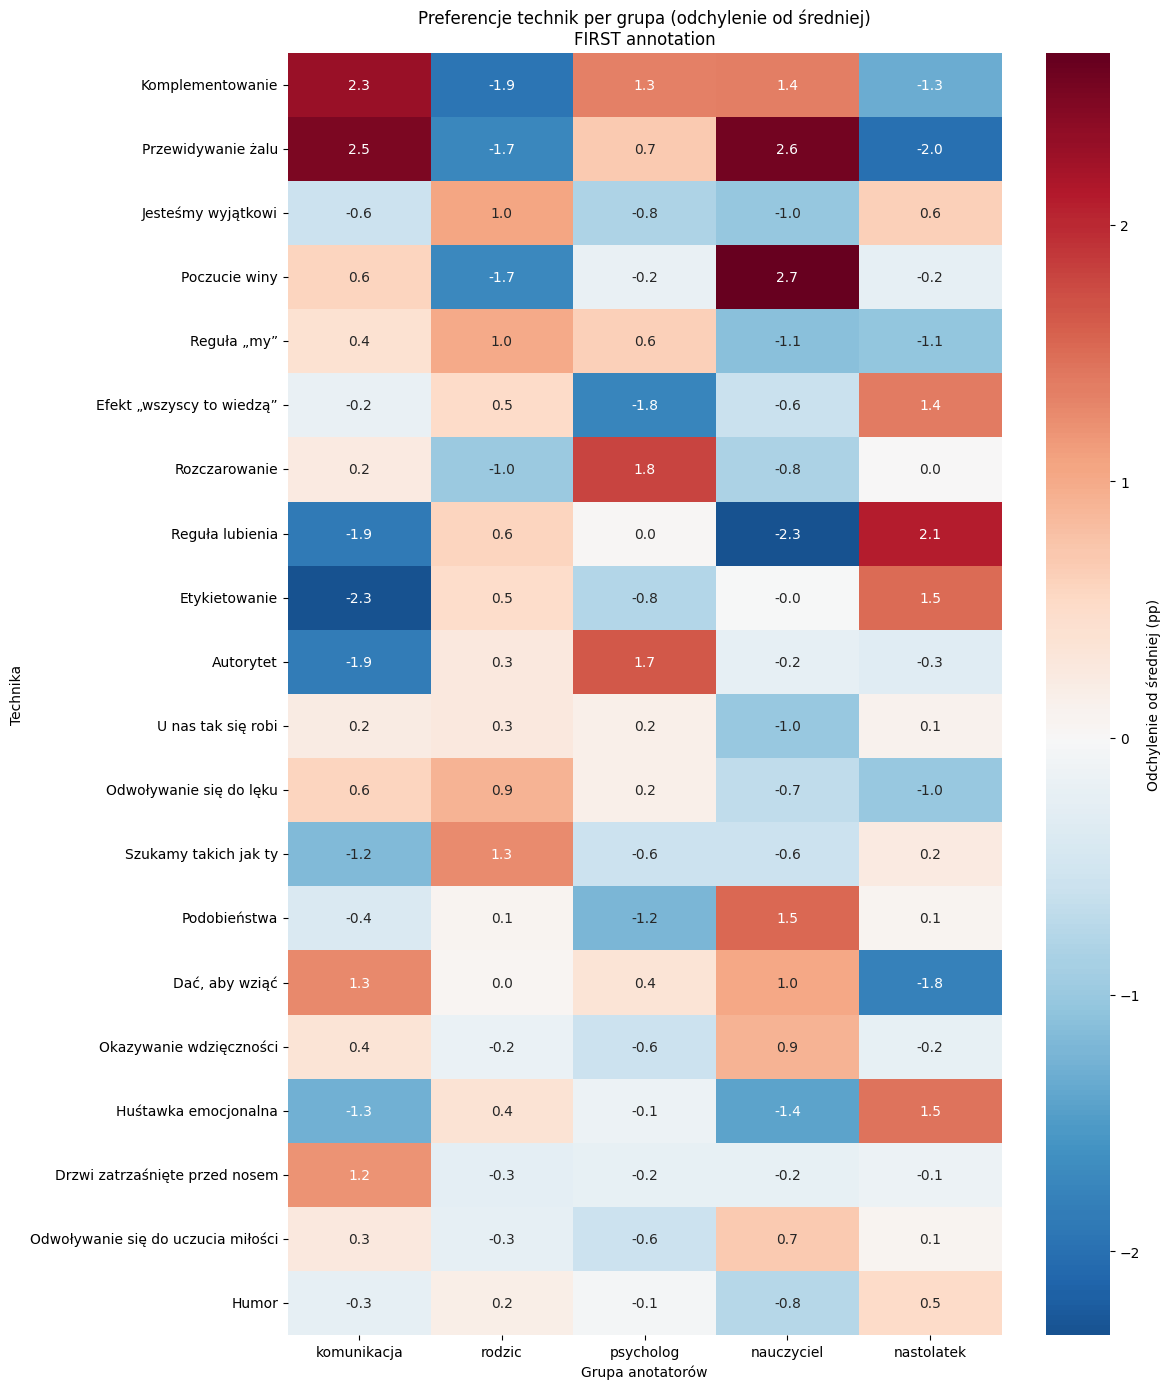

In [14]:
# Heatmap of group preferences (deviation from mean)
fig, ax = plt.subplots(figsize=(12, 14))

# Sort by overall frequency
sorted_techniques = group_first_df.sort_values('total', ascending=False).index
deviation_sorted = deviation_first.loc[sorted_techniques]

sns.heatmap(deviation_sorted, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Odchylenie od średniej (pp)'})
ax.set_title('Preferencje technik per grupa (odchylenie od średniej)\nFIRST annotation')
ax.set_xlabel('Grupa anotatorów')
ax.set_ylabel('Technika')

plt.tight_layout()
plt.savefig('../results/techniques_group_preferences.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# How do groups change between first and repeated?
group_change_df = pd.DataFrame(index=all_techniques)

for group in groups:
    first_counts = [first_per_group[group].get(t, 0) for t in all_techniques]
    repeated_counts = [repeated_per_group[group].get(t, 0) for t in all_techniques]
    group_change_df[group] = [r - f for f, r in zip(first_counts, repeated_counts)]

print('Zmiana częstości technik per grupa (repeated - first):')
print('(wartości dodatnie = wzrost użycia w repeated)')
print(group_change_df.to_string())

Zmiana częstości technik per grupa (repeated - first):
(wartości dodatnie = wzrost użycia w repeated)
                                    komunikacja  rodzic  psycholog  nauczyciel  nastolatek
Autorytet                                    12      -9         -4          -3          -7
Dać, aby wziąć                               16      -7         -1           0           0
Drzwi zatrzaśnięte przed nosem                3      -1          0           0           0
Efekt „wszyscy to wiedzą”                    10      -8         -4          11          -6
Etykietowanie                                33      14         -5          22         -19
Humor                                         3       1          0           1          -6
Huśtawka emocjonalna                         17      -6         -4           1         -13
Jesteśmy wyjątkowi                           22     -11         -8           8         -20
Komplementowanie                             10       0          0          -4 

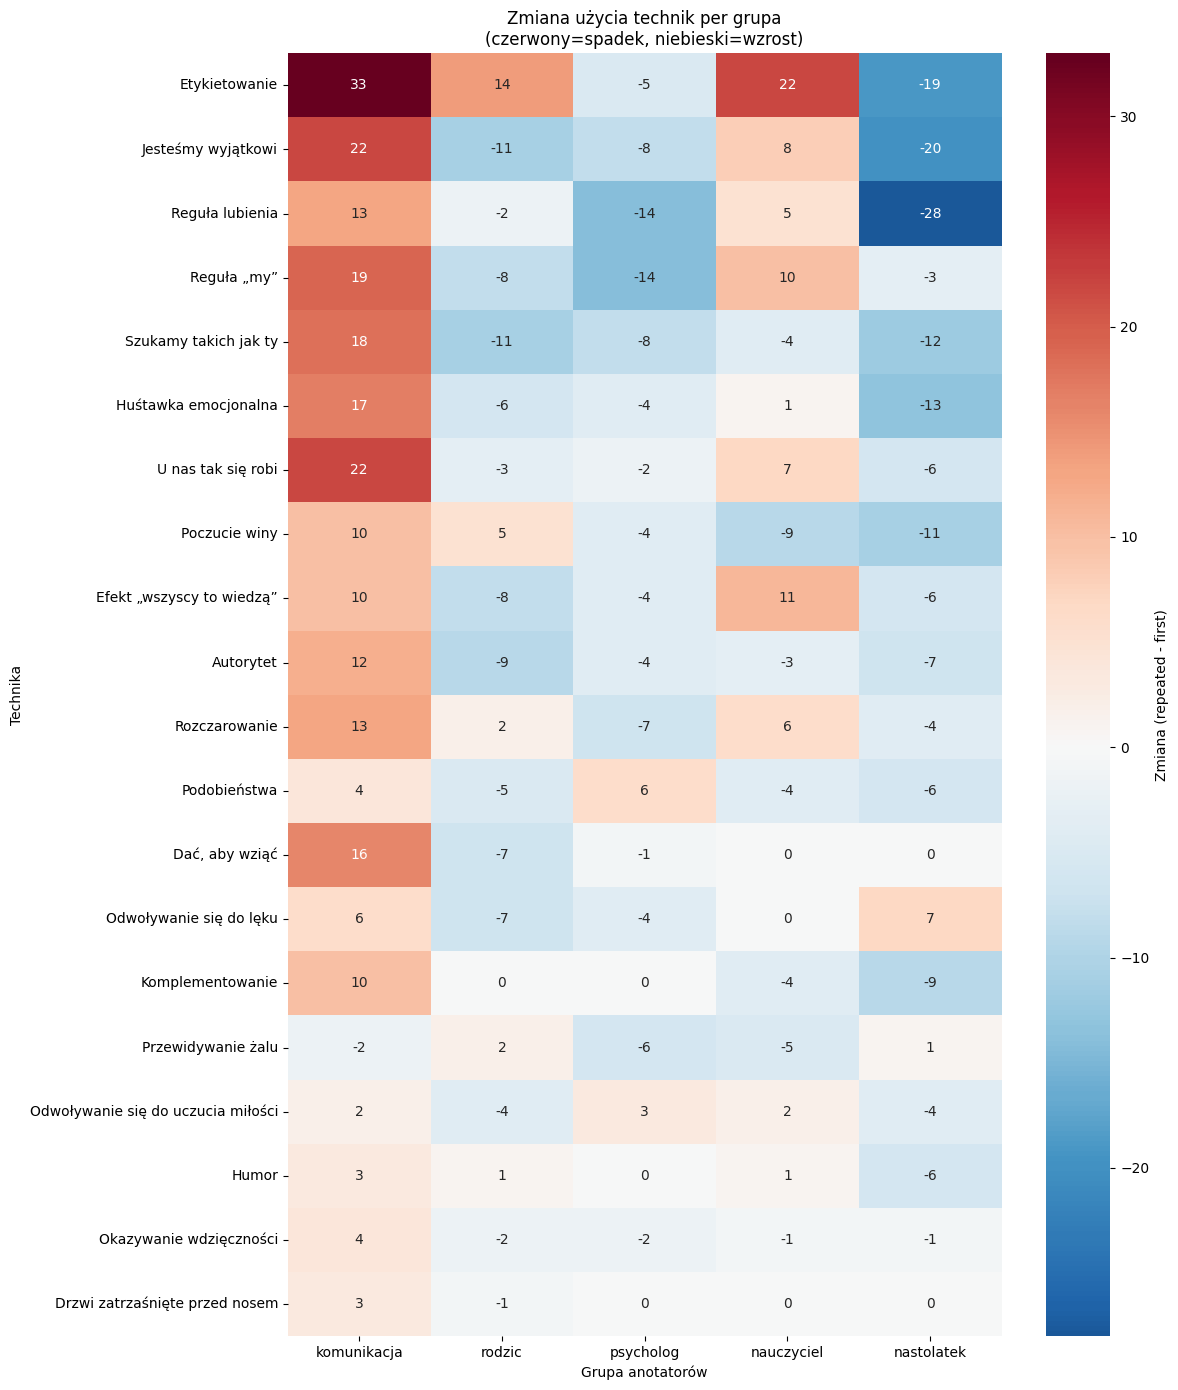

In [16]:
# Heatmap of changes per group
fig, ax = plt.subplots(figsize=(12, 14))

# Sort by total absolute change
group_change_df['abs_total'] = group_change_df.abs().sum(axis=1)
sorted_techniques = group_change_df.sort_values('abs_total', ascending=False).index
group_change_sorted = group_change_df.loc[sorted_techniques, groups]

sns.heatmap(group_change_sorted, annot=True, fmt='d', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Zmiana (repeated - first)'})
ax.set_title('Zmiana użycia technik per grupa\n(czerwony=spadek, niebieski=wzrost)')
ax.set_xlabel('Grupa anotatorów')
ax.set_ylabel('Technika')

plt.tight_layout()
plt.savefig('../results/techniques_group_changes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analiza niezgodności między grupami

In [17]:
# For each text, compare how different groups annotate it
# Focus on texts where same text was annotated by multiple groups

text_group_techniques = data.groupby(['id', 'annotator_group']).agg({
    'first_techniques_list': lambda x: [item for sublist in x for item in sublist],
    'repeated_techniques_list': lambda x: [item for sublist in x for item in sublist]
}).reset_index()

# For each text, calculate agreement between groups
def jaccard_similarity(set1, set2):
    if not set1 and not set2:
        return 1.0
    if not set1 or not set2:
        return 0.0
    return len(set1 & set2) / len(set1 | set2)

# Calculate inter-group agreement per text
text_ids = data['id'].unique()
group_pairs = list(combinations(groups, 2))

agreement_results = []
for text_id in text_ids:
    text_data = text_group_techniques[text_group_techniques['id'] == text_id]
    for g1, g2 in group_pairs:
        g1_data = text_data[text_data['annotator_group'] == g1]
        g2_data = text_data[text_data['annotator_group'] == g2]
        
        if len(g1_data) > 0 and len(g2_data) > 0:
            g1_first = set(g1_data.iloc[0]['first_techniques_list'])
            g2_first = set(g2_data.iloc[0]['first_techniques_list'])
            g1_repeated = set(g1_data.iloc[0]['repeated_techniques_list'])
            g2_repeated = set(g2_data.iloc[0]['repeated_techniques_list'])
            
            agreement_results.append({
                'text_id': text_id,
                'group_1': g1,
                'group_2': g2,
                'jaccard_first': jaccard_similarity(g1_first, g2_first),
                'jaccard_repeated': jaccard_similarity(g1_repeated, g2_repeated)
            })

agreement_df = pd.DataFrame(agreement_results)
print(f'Liczba porównań par grup: {len(agreement_df)}')

Liczba porównań par grup: 1500


In [18]:
# Summary of inter-group agreement
agreement_summary = agreement_df.groupby(['group_1', 'group_2']).agg({
    'jaccard_first': 'mean',
    'jaccard_repeated': 'mean'
}).round(3)

print('Średnia zgodność Jaccard między parami grup:')
print(agreement_summary.to_string())
print(f'\nŚrednia zgodność FIRST: {agreement_df["jaccard_first"].mean():.3f}')
print(f'Średnia zgodność REPEATED: {agreement_df["jaccard_repeated"].mean():.3f}')

Średnia zgodność Jaccard między parami grup:
                        jaccard_first  jaccard_repeated
group_1     group_2                                    
komunikacja nastolatek          0.407             0.110
            nauczyciel          0.379             0.352
            psycholog           0.435             0.317
            rodzic              0.373             0.312
nauczyciel  nastolatek          0.360             0.124
psycholog   nastolatek          0.364             0.123
            nauczyciel          0.357             0.381
rodzic      nastolatek          0.378             0.111
            nauczyciel          0.314             0.411
            psycholog           0.384             0.397

Średnia zgodność FIRST: 0.375
Średnia zgodność REPEATED: 0.264


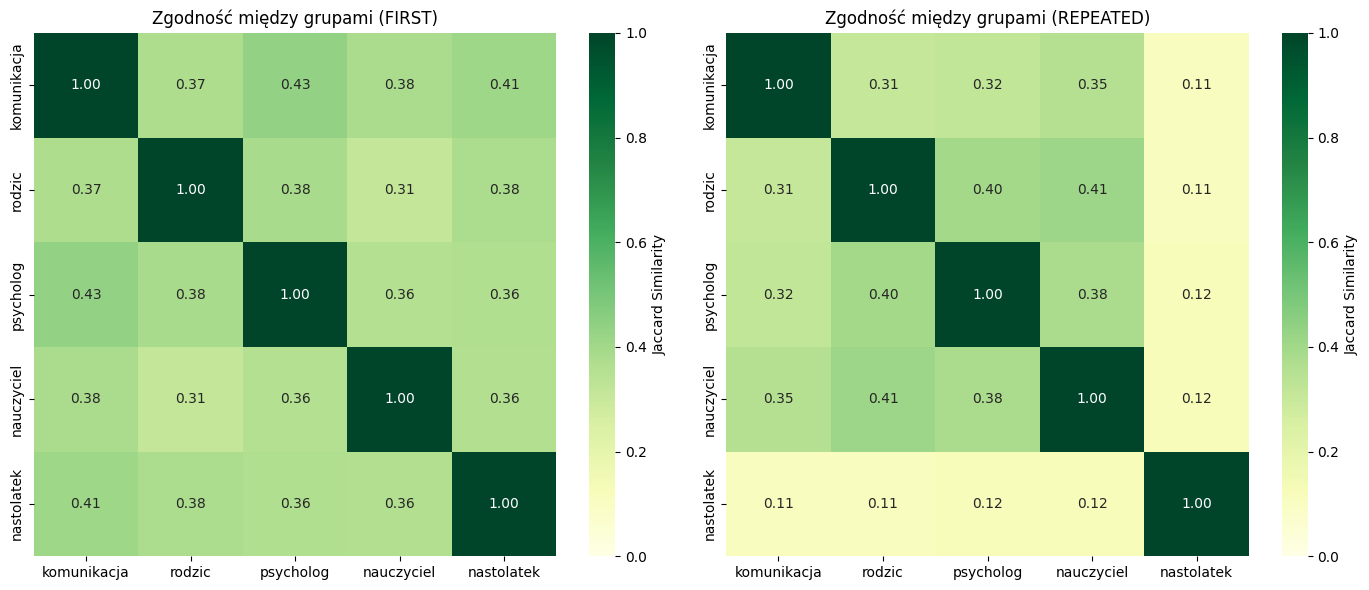

In [19]:
# Create agreement matrix
agreement_matrix_first = pd.DataFrame(index=groups, columns=groups, dtype=float)
agreement_matrix_repeated = pd.DataFrame(index=groups, columns=groups, dtype=float)

for _, row in agreement_summary.iterrows():
    g1, g2 = row.name
    agreement_matrix_first.loc[g1, g2] = row['jaccard_first']
    agreement_matrix_first.loc[g2, g1] = row['jaccard_first']
    agreement_matrix_repeated.loc[g1, g2] = row['jaccard_repeated']
    agreement_matrix_repeated.loc[g2, g1] = row['jaccard_repeated']

# Fill diagonal with 1
for g in groups:
    agreement_matrix_first.loc[g, g] = 1.0
    agreement_matrix_repeated.loc[g, g] = 1.0

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(agreement_matrix_first.astype(float), annot=True, fmt='.2f', cmap='YlGn', 
            ax=axes[0], vmin=0, vmax=1, cbar_kws={'label': 'Jaccard Similarity'})
axes[0].set_title('Zgodność między grupami (FIRST)')

sns.heatmap(agreement_matrix_repeated.astype(float), annot=True, fmt='.2f', cmap='YlGn', 
            ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Zgodność między grupami (REPEATED)')

plt.tight_layout()
plt.savefig('../results/techniques_group_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Which group is most "different" from others?
group_avg_agreement_first = agreement_matrix_first.mean(axis=1)
group_avg_agreement_repeated = agreement_matrix_repeated.mean(axis=1)

outlier_analysis = pd.DataFrame({
    'group': groups,
    'avg_agreement_first': group_avg_agreement_first.values,
    'avg_agreement_repeated': group_avg_agreement_repeated.values
})
outlier_analysis['agreement_change'] = outlier_analysis['avg_agreement_repeated'] - outlier_analysis['avg_agreement_first']

print('Średnia zgodność każdej grupy z innymi:')
print(outlier_analysis.sort_values('avg_agreement_first').to_string(index=False))
print('\n(niższa wartość = grupa bardziej "inna" od pozostałych)')

Średnia zgodność każdej grupy z innymi:
      group  avg_agreement_first  avg_agreement_repeated  agreement_change
 nauczyciel               0.4820                  0.4536           -0.0284
     rodzic               0.4898                  0.4462           -0.0436
 nastolatek               0.5018                  0.2936           -0.2082
  psycholog               0.5080                  0.4436           -0.0644
komunikacja               0.5188                  0.4182           -0.1006

(niższa wartość = grupa bardziej "inna" od pozostałych)


## 6. Szczegółowa analiza konkretnych technik

In [21]:
# Deep dive into most interesting techniques
# Based on previous analysis - techniques with high change or high variability

def analyze_technique(technique_name):
    print(f"\n{'='*60}")
    print(f"ANALIZA: {technique_name}")
    print(f"{'='*60}")
    
    # Overall stats
    first_count = first_counter[technique_name]
    repeated_count = repeated_counter[technique_name]
    print(f"\nCzęstość: first={first_count}, repeated={repeated_count}, diff={repeated_count-first_count}")
    
    # Per group
    print(f"\nPer grupa (first -> repeated):")
    for group in groups:
        f = first_per_group[group].get(technique_name, 0)
        r = repeated_per_group[group].get(technique_name, 0)
        print(f"  {group}: {f} -> {r} ({'+' if r-f >= 0 else ''}{r-f})")
    
    # Stability
    tech_data = change_analysis[change_analysis['technique'] == technique_name].iloc[0]
    print(f"\nStabilność: disappeared={tech_data['disappeared']}, kept={tech_data['kept']}, appeared={tech_data['appeared']}")
    if tech_data['first_count'] > 0:
        print(f"  Keep rate: {tech_data['keep_rate']}%")
    
    # Top substitutions
    tech_subst = substitutions_df[substitutions_df['disappeared'] == technique_name].head(5)
    if len(tech_subst) > 0:
        print(f"\nGdy znika, pojawia się:")
        for _, row in tech_subst.iterrows():
            print(f"  -> {row['appeared']}: {row['count']}x")
    
    tech_subst_rev = substitutions_df[substitutions_df['appeared'] == technique_name].head(5)
    if len(tech_subst_rev) > 0:
        print(f"\nGdy pojawia się, znikło:")
        for _, row in tech_subst_rev.iterrows():
            print(f"  <- {row['disappeared']}: {row['count']}x")

# Analyze top techniques
top_techniques = ['Autorytet', 'Reguła lubienia', 'Etykietowanie', 'Poczucie winy', 
                  'Odwoływanie się do lęku', 'Przewidywanie żalu']

for tech in top_techniques:
    analyze_technique(tech)


ANALIZA: Autorytet

Częstość: first=89, repeated=78, diff=-11

Per grupa (first -> repeated):
  komunikacja: 8 -> 20 (+12)
  rodzic: 24 -> 15 (-9)
  psycholog: 23 -> 19 (-4)
  nauczyciel: 14 -> 11 (-3)
  nastolatek: 20 -> 13 (-7)

Stabilność: disappeared=56, kept=33, appeared=45
  Keep rate: 37.1%

Gdy znika, pojawia się:
  -> Przewidywanie żalu: 7x
  -> Jesteśmy wyjątkowi: 6x
  -> Podobieństwa: 5x
  -> Rozczarowanie: 5x
  -> Odwoływanie się do lęku: 5x

Gdy pojawia się, znikło:
  <- Etykietowanie: 6x
  <- Szukamy takich jak ty: 5x
  <- Podobieństwa: 5x
  <- Efekt „wszyscy to wiedzą”: 5x
  <- Komplementowanie: 5x

ANALIZA: Reguła lubienia

Częstość: first=103, repeated=77, diff=-26

Per grupa (first -> repeated):
  komunikacja: 10 -> 23 (+13)
  rodzic: 29 -> 27 (-2)
  psycholog: 20 -> 6 (-14)
  nauczyciel: 10 -> 15 (+5)
  nastolatek: 34 -> 6 (-28)

Stabilność: disappeared=85, kept=18, appeared=59
  Keep rate: 17.5%

Gdy znika, pojawia się:
  -> Przewidywanie żalu: 15x
  -> Odwoływanie

## 7. Podsumowanie i wnioski

In [22]:
print("="*70)
print("PODSUMOWANIE ANALIZY TECHNIK PERSWAZJI")
print("="*70)

print("\n1. OGÓLNE STATYSTYKI")
print(f"   - Liczba obserwacji: {len(data)}")
print(f"   - Unikalne teksty: {data['id'].nunique()}")
print(f"   - Unikalne techniki: {len(all_techniques)}")
print(f"   - Suma technik (first): {sum(first_counter.values())}")
print(f"   - Suma technik (repeated): {sum(repeated_counter.values())}")

print("\n2. TECHNIKI NAJCZĘŚCIEJ ZNIKAJĄCE (top 5):")
top_disappeared = change_analysis.nlargest(5, 'disappeared')[['technique', 'disappeared', 'disappear_rate']]
for _, row in top_disappeared.iterrows():
    print(f"   - {row['technique']}: {row['disappeared']}x ({row['disappear_rate']}% wskaźnik znikania)")

print("\n3. TECHNIKI NAJCZĘŚCIEJ POJAWIAJĄCE SIĘ (top 5):")
top_appeared = change_analysis.nlargest(5, 'appeared')[['technique', 'appeared']]
for _, row in top_appeared.iterrows():
    print(f"   - {row['technique']}: {row['appeared']}x")

print("\n4. NAJBARDZIEJ STABILNE TECHNIKI (keep rate, min 20 w first):")
stable = change_analysis[change_analysis['first_count'] >= 20].nlargest(5, 'keep_rate')
for _, row in stable.iterrows():
    print(f"   - {row['technique']}: {row['keep_rate']}% zachowane")

print("\n5. NAJCZĘSTSZE 'ZAMIANY' TECHNIK:")
for _, row in substitutions_df.head(5).iterrows():
    print(f"   - {row['disappeared']} -> {row['appeared']}: {row['count']}x")

print("\n6. GRUPY - NAJWIĘKSZE BIASY (odchylenie od średniej):")
# Find biggest deviations per group
for group in groups:
    max_positive = deviation_first[group].idxmax()
    max_negative = deviation_first[group].idxmin()
    print(f"   {group}:")
    print(f"     + nadreprezentacja: {max_positive} ({deviation_first.loc[max_positive, group]:+.1f}pp)")
    print(f"     - niedoreprezentacja: {max_negative} ({deviation_first.loc[max_negative, group]:+.1f}pp)")

print("\n7. ZGODNOŚĆ MIĘDZY GRUPAMI:")
print(f"   - Średnia zgodność (first): {agreement_df['jaccard_first'].mean():.3f}")
print(f"   - Średnia zgodność (repeated): {agreement_df['jaccard_repeated'].mean():.3f}")
most_similar = agreement_summary['jaccard_first'].idxmax()
least_similar = agreement_summary['jaccard_first'].idxmin()
print(f"   - Najbardziej zgodne grupy: {most_similar} (Jaccard={agreement_summary.loc[most_similar, 'jaccard_first']:.3f})")
print(f"   - Najmniej zgodne grupy: {least_similar} (Jaccard={agreement_summary.loc[least_similar, 'jaccard_first']:.3f})")

PODSUMOWANIE ANALIZY TECHNIK PERSWAZJI

1. OGÓLNE STATYSTYKI
   - Liczba obserwacji: 750
   - Unikalne teksty: 150
   - Unikalne techniki: 20
   - Suma technik (first): 1823
   - Suma technik (repeated): 1816

2. TECHNIKI NAJCZĘŚCIEJ ZNIKAJĄCE (top 5):
   - Jesteśmy wyjątkowi: 87x (64.9% wskaźnik znikania)
   - Reguła lubienia: 85x (82.5% wskaźnik znikania)
   - Przewidywanie żalu: 84x (54.9% wskaźnik znikania)
   - Reguła „my”: 77x (62.6% wskaźnik znikania)
   - Etykietowanie: 75x (77.3% wskaźnik znikania)

3. TECHNIKI NAJCZĘŚCIEJ POJAWIAJĄCE SIĘ (top 5):
   - Etykietowanie: 120x
   - Reguła „my”: 81x
   - Jesteśmy wyjątkowi: 78x
   - U nas tak się robi: 77x
   - Przewidywanie żalu: 74x

4. NAJBARDZIEJ STABILNE TECHNIKI (keep rate, min 20 w first):
   - Komplementowanie: 60.5% zachowane
   - Drzwi zatrzaśnięte przed nosem: 57.5% zachowane
   - Rozczarowanie: 51.8% zachowane
   - Dać, aby wziąć: 48.5% zachowane
   - Poczucie winy: 48.1% zachowane

5. NAJCZĘSTSZE 'ZAMIANY' TECHNIK:
   -